# Forecast-Driven Signal Timing Strategy Comparison

This notebook compares a fixed-time baseline signal timing strategy with a simplified demand-responsive timing strategy using the short-term traffic demand forecasts generated in notebook 07. The analysis translates forecast output into operational performance indicators so the capstone can assess whether forecast-informed timing adjustments improve corridor efficiency, especially during congested periods.


## 1. Title and Objective

This notebook uses the forecasted traffic demand output from notebook 07 to compare a fixed-time baseline signal timing strategy with a demand-responsive alternative. The objective is to determine whether forecast-informed signal timing can improve relative operational performance, especially under higher-demand conditions, while maintaining a transparent and presentation-ready analytical workflow.


## 2. Load Forecast-Based Traffic Demand

This section loads the traffic demand forecasts exported from notebook 07 and validates that the data contains the columns required for downstream signal timing analysis. The workflow automatically identifies the datetime field, standardizes key labels, and prepares the forecast table in chronological order so the later simulation remains reproducible and interpretable.


In [105]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
pd.set_option('display.max_columns', 50)

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

data_dir = project_root / 'data' / 'processed'
figures_dir = project_root / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

forecast_path = data_dir / 'traffic_demand_forecasts.csv'
model_results_path = data_dir / 'forecast_model_results.csv'
ablation_results_path = data_dir / 'forecast_ablation_results.csv'

if not forecast_path.exists():
    raise FileNotFoundError(
        f'Forecast file not found at {forecast_path}. Run notebook 07 before executing this notebook.'
    )

forecast_df = pd.read_csv(forecast_path)
display(Markdown(f'Loaded **{forecast_df.shape[0]:,}** forecast rows and **{forecast_df.shape[1]}** columns from `{forecast_path.relative_to(project_root)}`.'))
forecast_df.head()


Loaded **19,200** forecast rows and **6** columns from `data/processed/traffic_demand_forecasts.csv`.

,location_id,nearest_signal_id,forecast_timestamp,actual_volume,predicted_volume,model_name
0,10154405_WB,8741191.0,2019-01-13 00:00:00,199.0,240.359650,GRU
1,1139432_EB,NaN,2019-01-13 00:00:00,331.0,335.990234,GRU
2,1140808_WB,1140808.0,2019-01-13 00:00:00,204.0,263.463531,GRU
3,1140818_WB,1140818.0,2019-01-13 00:00:00,85.0,157.198502,GRU
4,1140855_EB,1140818.0,2019-01-13 00:00:00,114.0,203.954880,GRU


In [106]:
datetime_candidates = [
    'forecast_timestamp',
    'timestamp',
    'date',
    'datetime',
    'ds',
    'hour',
]
datetime_col = next((col for col in datetime_candidates if col in forecast_df.columns), None)
if datetime_col is None:
    raise ValueError(
        'No datetime column was found. Expected one of: ' + ', '.join(datetime_candidates)
    )

required_cols = {'predicted_volume', 'model_name'}
missing_required = sorted(required_cols - set(forecast_df.columns))
if missing_required:
    raise ValueError(
        'The forecast dataset is missing required columns for signal timing analysis: ' + ', '.join(missing_required)
    )

if 'location_id' not in forecast_df.columns:
    forecast_df['location_id'] = 'all_locations'

forecast_df[datetime_col] = pd.to_datetime(forecast_df[datetime_col], errors='coerce')
if forecast_df[datetime_col].isna().all():
    raise ValueError(f'Unable to parse datetime values from column `{datetime_col}`.')

missing_predicted_rows = forecast_df['predicted_volume'].isna().sum()
negative_predicted_rows = (forecast_df['predicted_volume'] < 0).sum()

forecast_df = forecast_df.dropna(subset=[datetime_col, 'predicted_volume']).copy()
forecast_df = forecast_df.loc[forecast_df['predicted_volume'] >= 0].copy()
forecast_df = forecast_df.rename(columns={datetime_col: 'analysis_timestamp'})
forecast_df['model_name'] = forecast_df['model_name'].astype(str).str.strip()
forecast_df = forecast_df.sort_values(['location_id', 'analysis_timestamp']).reset_index(drop=True)

removed_predicted_rows = int(missing_predicted_rows + negative_predicted_rows)
if removed_predicted_rows > 0:
    display(Markdown(
        f'Removed **{removed_predicted_rows:,}** forecast rows during predicted-volume validation: **{missing_predicted_rows:,}** with missing predictions and **{negative_predicted_rows:,}** with negative predictions.'
    ))

display(Markdown(
    f'Using `{datetime_col}` as the analysis timestamp field. The cleaned dataset covers **{forecast_df["location_id"].nunique():,}** location(s) across **{forecast_df["analysis_timestamp"].min():%Y-%m-%d}** to **{forecast_df["analysis_timestamp"].max():%Y-%m-%d}**.'
))
forecast_df[['location_id', 'analysis_timestamp', 'predicted_volume', 'model_name']].head()


Removed **101** forecast rows during predicted-volume validation: **0** with missing predictions and **101** with negative predictions.

Using `forecast_timestamp` as the analysis timestamp field. The cleaned dataset covers **35** location(s) across **2019-01-13** to **2019-11-05**.

,location_id,analysis_timestamp,predicted_volume,model_name
0,10133019_NB,2019-02-06 00:00:00,17.381624,GRU
1,10133019_NB,2019-02-06 00:00:00,37.489132,LSTM
2,10133019_NB,2019-02-06 00:00:00,55.683504,Random Forest
3,10133019_NB,2019-02-06 01:00:00,38.242649,LSTM
4,10133019_NB,2019-02-06 01:00:00,48.178560,Random Forest


## 3. Select Best Forecasting Model

Because notebook 07 evaluated several forecasting models, this section identifies the best available model before any signal timing simulation is performed. Only the best-performing model's forecast output is used in the operational comparison so that the signal timing analysis is grounded in the strongest predictive evidence available in the project outputs.


In [107]:
model_results_df = None
ablation_results_df = None
best_model_name = 'Random Forest'

if model_results_path.exists():
    model_results_df = pd.read_csv(model_results_path)
    rmse_candidates = ['RMSE', 'rmse', 'test_rmse', 'validation_rmse']
    rmse_col = next((col for col in rmse_candidates if col in model_results_df.columns), None)
    model_col_candidates = ['model_name', 'model', 'Model']
    model_col = next((col for col in model_col_candidates if col in model_results_df.columns), None)
    if rmse_col is None or model_col is None:
        raise ValueError('`forecast_model_results.csv` exists but does not contain recognizable model name and RMSE columns.')
    best_row = model_results_df.sort_values(rmse_col, ascending=True).iloc[0]
    best_model_name = str(best_row[model_col]).strip()
    display(Markdown(
        f'Selected **{best_model_name}** as the best forecasting model because it has the lowest available RMSE (**{best_row[rmse_col]:.3f}**).'
    ))
    display(model_results_df.sort_values(rmse_col).reset_index(drop=True))
else:
    display(Markdown('`forecast_model_results.csv` was not found, so the notebook falls back to **Random Forest** as the default best model.'))

if ablation_results_path.exists():
    ablation_results_df = pd.read_csv(ablation_results_path)
    display(Markdown('Supplementary ablation results are available and are shown below as supporting context for the forecasting stage.'))
    display(ablation_results_df.head())

analysis_df = forecast_df.loc[forecast_df['model_name'].eq(best_model_name)].copy()
if analysis_df.empty:
    display(Markdown(
        f'Warning: no forecast rows matched **{best_model_name}**. The notebook will continue using all forecast rows instead.'
    ))
    analysis_df = forecast_df.copy()

analysis_df['selected_model_name'] = best_model_name
display(Markdown(f'Analysis dataset contains **{analysis_df.shape[0]:,}** rows after model selection.'))
analysis_df[['location_id', 'analysis_timestamp', 'predicted_volume', 'model_name']].head()


Selected **Random Forest** as the best forecasting model because it has the lowest available RMSE (**55.292**).

,model_name,RMSE,MAE
0,Random Forest,55.292001,36.901536
1,GRU,55.626711,39.053702
2,LSTM,56.081842,38.982484
3,TCN,66.722222,42.485575


Supplementary ablation results are available and are shown below as supporting context for the forecasting stage.

,model_name,feature_set,RMSE,MAE
0,Random Forest,Feature Set D: Full Feature Set,56.684351,37.469147
1,Random Forest,Feature Set B: Temporal + Lag,95.867912,59.680069
2,Random Forest,Feature Set C: Temporal + Lag + Rolling,98.405769,53.299828
3,Random Forest,Feature Set A: Temporal Only,177.697613,115.341330


Analysis dataset contains **4,800** rows after model selection.

,location_id,analysis_timestamp,predicted_volume,model_name
2,10133019_NB,2019-02-06 00:00:00,55.683504,Random Forest
4,10133019_NB,2019-02-06 01:00:00,48.178560,Random Forest
6,10133019_NB,2019-02-06 02:00:00,48.178560,Random Forest
8,10133019_NB,2019-02-06 03:00:00,48.259560,Random Forest
10,10133019_NB,2019-02-06 04:00:00,48.391782,Random Forest


The operational simulation below uses only the forecast output generated by the selected best-performing model. This short verification step confirms the model choice and checks that the analysis dataset is restricted to the expected forecast source.


In [108]:
print("Selected forecasting model for signal timing analysis:", best_model_name)
display(analysis_df["model_name"].value_counts())


Selected forecasting model for signal timing analysis: Random Forest


model_name
Random Forest    4800
Name: count, dtype: int64

The following validation summary confirms the scope of the cleaned analysis dataset before the signal timing calculations begin.


In [109]:
print("Locations analyzed:", analysis_df["location_id"].nunique())
print("Forecast rows used:", len(analysis_df))
print("Time range:", analysis_df["analysis_timestamp"].min(), "to", analysis_df["analysis_timestamp"].max())


Locations analyzed: 35
Forecast rows used: 4800
Time range: 2019-01-13 00:00:00 to 2019-11-05 23:00:00


## 4. Operational Assumptions and Simplifications

This notebook presents a simplified forecast-informed signal timing comparison rather than a fully calibrated traffic engineering control system. To keep the operational comparison transparent, cycle length, green allocation, and saturation flow are treated as fixed assumptions, while the optimized strategy applies a heuristic demand-responsive rule based on forecasted traffic volume. The resulting traffic metrics should therefore be interpreted as comparative operational indicators of delay, queue formation, and throughput across scenarios, not as exact field-measured delays or fully validated intersection control outcomes.


## 5. Baseline Signal Timing Assumptions

A baseline fixed-time strategy provides the reference case for comparison. In this notebook, every observation receives the same cycle length and green allocation, which reflects a transparent but non-adaptive control plan. This baseline matters because it establishes the operational benchmark that the forecast-driven strategy must outperform to justify added complexity.


In [110]:
PEAK_HOURS = {7, 8, 9, 16, 17, 18, 19}
BASE_CYCLE = 120
BASE_GREEN = 50
SAT_FLOW_PER_HOUR = 1800

analysis_df['hour'] = analysis_df['analysis_timestamp'].dt.hour
analysis_df['day_of_week'] = analysis_df['analysis_timestamp'].dt.day_name()
analysis_df['month'] = analysis_df['analysis_timestamp'].dt.month_name()
analysis_df['is_peak_period'] = analysis_df['hour'].isin(PEAK_HOURS)

analysis_df['baseline_cycle_length'] = BASE_CYCLE
analysis_df['baseline_green'] = BASE_GREEN
analysis_df['baseline_capacity_vph'] = (
    analysis_df['baseline_green'] / analysis_df['baseline_cycle_length']
) * SAT_FLOW_PER_HOUR

display(Markdown(
    'Peak periods are evaluated separately because congestion management is most critical when demand is concentrated in morning and afternoon commuter windows. The baseline scenario therefore serves as a stable fixed-time reference against which forecast-responsive timing adjustments can be judged.'
))
analysis_df[[
    'location_id', 'analysis_timestamp', 'predicted_volume', 'hour', 'is_peak_period',
    'baseline_cycle_length', 'baseline_green', 'baseline_capacity_vph'
]].head()


Peak periods are evaluated separately because congestion management is most critical when demand is concentrated in morning and afternoon commuter windows. The baseline scenario therefore serves as a stable fixed-time reference against which forecast-responsive timing adjustments can be judged.

,location_id,analysis_timestamp,predicted_volume,hour,is_peak_period,baseline_cycle_length,baseline_green,baseline_capacity_vph
2,10133019_NB,2019-02-06 00:00:00,55.683504,0,False,120,50,750.0
4,10133019_NB,2019-02-06 01:00:00,48.178560,1,False,120,50,750.0
6,10133019_NB,2019-02-06 02:00:00,48.178560,2,False,120,50,750.0
8,10133019_NB,2019-02-06 03:00:00,48.259560,3,False,120,50,750.0
10,10133019_NB,2019-02-06 04:00:00,48.391782,4,False,120,50,750.0


## 6. Optimized Signal Timing Strategy

The optimized scenario now uses a continuous demand-responsive allocation rule based on baseline volume-to-capacity conditions rather than abrupt demand thresholds. For a clearer operational comparison, cycle length is held fixed across both scenarios and only green allocation is adjusted in response to forecasted congestion. This avoids conflating green-time improvement with longer cycle effects and helps isolate the benefit of demand-responsive green allocation.


In [111]:
analysis_df['baseline_vc_ratio'] = analysis_df['predicted_volume'] / analysis_df['baseline_capacity_vph']

alpha = 25
analysis_df['optimized_green'] = BASE_GREEN + alpha * (analysis_df['baseline_vc_ratio'] - 1)
analysis_df['optimized_green'] = np.clip(analysis_df['optimized_green'], BASE_GREEN, 80)
analysis_df['optimized_cycle_length'] = BASE_CYCLE
analysis_df['optimized_capacity_vph'] = (
    analysis_df['optimized_green'] / analysis_df['optimized_cycle_length']
) * SAT_FLOW_PER_HOUR

display(Markdown(
    'The optimized strategy scales green time gradually as baseline v/c conditions become more demanding while keeping cycle length fixed. This isolates the operational effect of adaptive green allocation and supports a cleaner baseline-versus-optimized comparison.'
))
analysis_df[[
    'predicted_volume', 'baseline_vc_ratio', 'baseline_green', 'optimized_green',
    'baseline_cycle_length', 'optimized_cycle_length',
    'baseline_capacity_vph', 'optimized_capacity_vph'
]].head()


The optimized strategy scales green time gradually as baseline v/c conditions become more demanding while keeping cycle length fixed. This isolates the operational effect of adaptive green allocation and supports a cleaner baseline-versus-optimized comparison.

,predicted_volume,baseline_vc_ratio,baseline_green,optimized_green,baseline_cycle_length,optimized_cycle_length,baseline_capacity_vph,optimized_capacity_vph
2,55.683504,0.074245,50,50.0,120,120,750.0,750.0
4,48.178560,0.064238,50,50.0,120,120,750.0,750.0
6,48.178560,0.064238,50,50.0,120,120,750.0,750.0
8,48.259560,0.064346,50,50.0,120,120,750.0,750.0
10,48.391782,0.064522,50,50.0,120,120,750.0,750.0


## 7. Traffic Flow Performance Metrics

With both timing plans defined, the notebook derives traffic flow performance metrics for comparative evaluation. Delay is now estimated using a simplified Webster-style uniform control delay formulation, which provides an approximate average delay per vehicle in seconds under each timing scenario. Volume-to-capacity ratio remains a supporting diagnostic metric, while delay, queue pressure, and throughput form the main basis for operational comparison.


In [112]:
def webster_delay(volume, capacity, green, cycle):
    """
    Approximate average control delay per vehicle (seconds)
    using a simplified Webster uniform delay formula.
    """
    if capacity <= 0 or cycle <= 0 or green <= 0:
        return np.nan

    x = volume / capacity
    g_over_c = green / cycle
    capped_x = min(1.0, x)

    denominator = 1 - (capped_x * g_over_c)
    if denominator <= 0:
        return np.nan

    delay = (0.5 * cycle * (1 - g_over_c) ** 2) / denominator
    return delay

analysis_df['optimized_capacity_vph'] = (
    analysis_df['optimized_green'] / analysis_df['optimized_cycle_length']
) * SAT_FLOW_PER_HOUR
analysis_df['optimized_vc_ratio'] = analysis_df['predicted_volume'] / analysis_df['optimized_capacity_vph']

analysis_df['baseline_delay_sec'] = analysis_df.apply(
    lambda row: webster_delay(
        row['predicted_volume'],
        row['baseline_capacity_vph'],
        row['baseline_green'],
        row['baseline_cycle_length'],
    ),
    axis=1,
)
analysis_df['optimized_delay_sec'] = analysis_df.apply(
    lambda row: webster_delay(
        row['predicted_volume'],
        row['optimized_capacity_vph'],
        row['optimized_green'],
        row['optimized_cycle_length'],
    ),
    axis=1,
)

analysis_df['baseline_queue_pressure'] = np.maximum(analysis_df['predicted_volume'] - analysis_df['baseline_capacity_vph'], 0)
analysis_df['optimized_queue_pressure'] = np.maximum(analysis_df['predicted_volume'] - analysis_df['optimized_capacity_vph'], 0)
analysis_df['baseline_throughput'] = np.minimum(analysis_df['predicted_volume'], analysis_df['baseline_capacity_vph'])
analysis_df['optimized_throughput'] = np.minimum(analysis_df['predicted_volume'], analysis_df['optimized_capacity_vph'])

analysis_df['delay_reduction_sec'] = analysis_df['baseline_delay_sec'] - analysis_df['optimized_delay_sec']
analysis_df['queue_pressure_reduction'] = analysis_df['baseline_queue_pressure'] - analysis_df['optimized_queue_pressure']
analysis_df['throughput_gain'] = analysis_df['optimized_throughput'] - analysis_df['baseline_throughput']

detailed_results_columns = [
    'analysis_timestamp', 'location_id', 'model_name', 'selected_model_name', 'predicted_volume',
    'baseline_capacity_vph', 'optimized_capacity_vph',
    'baseline_delay_sec', 'optimized_delay_sec',
    'baseline_queue_pressure', 'optimized_queue_pressure',
    'baseline_throughput', 'optimized_throughput',
    'delay_reduction_sec', 'queue_pressure_reduction', 'throughput_gain',
    'is_peak_period'
]
optional_detailed_columns = [
    'nearest_signal_id', 'actual_volume', 'hour', 'day_of_week', 'month', 'traffic_level',
    'baseline_cycle_length', 'baseline_green', 'optimized_cycle_length', 'optimized_green',
    'baseline_vc_ratio', 'optimized_vc_ratio'
]
detailed_results_columns.extend(
    [col for col in optional_detailed_columns if col in analysis_df.columns and col not in detailed_results_columns]
)

detailed_results_path = data_dir / 'signal_timing_strategy_detailed_results.csv'
analysis_df[detailed_results_columns].round(3).to_csv(detailed_results_path, index=False)

metric_preview_columns = [
    'location_id', 'analysis_timestamp', 'predicted_volume',
    'baseline_delay_sec', 'optimized_delay_sec',
    'baseline_queue_pressure', 'optimized_queue_pressure',
    'baseline_throughput', 'optimized_throughput',
    'delay_reduction_sec', 'queue_pressure_reduction', 'throughput_gain'
]

display(Markdown(
    'The delay values reported below are approximate control-delay estimates in seconds per vehicle based on a simplified Webster formulation. They are intended for scenario comparison rather than precise field calibration.'
))
analysis_df[metric_preview_columns].head()


The delay values reported below are approximate control-delay estimates in seconds per vehicle based on a simplified Webster formulation. They are intended for scenario comparison rather than precise field calibration.

,location_id,analysis_timestamp,predicted_volume,baseline_delay_sec,optimized_delay_sec,baseline_queue_pressure,optimized_queue_pressure,baseline_throughput,optimized_throughput,delay_reduction_sec,queue_pressure_reduction,throughput_gain
2,10133019_NB,2019-02-06 00:00:00,55.683504,21.068424,21.068424,0.0,0.0,55.683504,55.683504,0.0,0.0,0.0
4,10133019_NB,2019-02-06 01:00:00,48.178560,20.978165,20.978165,0.0,0.0,48.178560,48.178560,0.0,0.0,0.0
6,10133019_NB,2019-02-06 02:00:00,48.178560,20.978165,20.978165,0.0,0.0,48.178560,48.178560,0.0,0.0,0.0
8,10133019_NB,2019-02-06 03:00:00,48.259560,20.979135,20.979135,0.0,0.0,48.259560,48.259560,0.0,0.0,0.0
10,10133019_NB,2019-02-06 04:00:00,48.391782,20.980719,20.980719,0.0,0.0,48.391782,48.391782,0.0,0.0,0.0


In [113]:
print('Baseline cycle length:', BASE_CYCLE)
print('Optimized cycle length unique values:', analysis_df['optimized_cycle_length'].unique())
print('Optimized green range:', round(analysis_df['optimized_green'].min(), 3), 'to', round(analysis_df['optimized_green'].max(), 3))


Baseline cycle length: 120
Optimized cycle length unique values: [120]
Optimized green range: 50.0 to 80.0


## 8. Baseline vs Optimized Comparison

This section aggregates the simulation outputs into a clean summary table that compares the baseline and optimized timing strategies across overall and peak-period metrics. The goal is to present a concise decision-oriented view of whether forecast-informed signal timing improves system performance enough to matter for the capstone’s smart traffic operations objective.


In [114]:
summary_rows = [
    {
        'Metric': 'Average delay (sec/veh)',
        'Baseline': analysis_df['baseline_delay_sec'].mean(),
        'Optimized': analysis_df['optimized_delay_sec'].mean(),
    },
    {
        'Metric': 'Average throughput',
        'Baseline': analysis_df['baseline_throughput'].mean(),
        'Optimized': analysis_df['optimized_throughput'].mean(),
    },
    {
        'Metric': 'Average queue pressure',
        'Baseline': analysis_df['baseline_queue_pressure'].mean(),
        'Optimized': analysis_df['optimized_queue_pressure'].mean(),
    },
    {
        'Metric': 'Peak-period delay (sec/veh)',
        'Baseline': analysis_df.loc[analysis_df['is_peak_period'], 'baseline_delay_sec'].mean(),
        'Optimized': analysis_df.loc[analysis_df['is_peak_period'], 'optimized_delay_sec'].mean(),
    },
    {
        'Metric': 'Peak-period throughput',
        'Baseline': analysis_df.loc[analysis_df['is_peak_period'], 'baseline_throughput'].mean(),
        'Optimized': analysis_df.loc[analysis_df['is_peak_period'], 'optimized_throughput'].mean(),
    },
    {
        'Metric': 'Peak-period queue pressure',
        'Baseline': analysis_df.loc[analysis_df['is_peak_period'], 'baseline_queue_pressure'].mean(),
        'Optimized': analysis_df.loc[analysis_df['is_peak_period'], 'optimized_queue_pressure'].mean(),
    },
]

summary_df = pd.DataFrame(summary_rows)
summary_df['Improvement'] = np.where(
    summary_df['Metric'].str.contains('throughput', case=False),
    summary_df['Optimized'] - summary_df['Baseline'],
    summary_df['Baseline'] - summary_df['Optimized'],
)

summary_output_path = data_dir / 'signal_timing_comparison_summary.csv'
summary_df.round(3).to_csv(summary_output_path, index=False)

display(summary_df.round(3))

average_delay_reduction_sec = summary_df.loc[summary_df['Metric'].eq('Average delay (sec/veh)'), 'Improvement'].iloc[0]
overall_queue_baseline = summary_df.loc[summary_df['Metric'].eq('Average queue pressure'), 'Baseline'].iloc[0]
overall_queue_change_pct = 0.0 if overall_queue_baseline == 0 else (
    summary_df.loc[summary_df['Metric'].eq('Average queue pressure'), 'Improvement'].iloc[0]
    / overall_queue_baseline
) * 100
overall_throughput_change_pct = (
    summary_df.loc[summary_df['Metric'].eq('Average throughput'), 'Improvement'].iloc[0]
    / summary_df.loc[summary_df['Metric'].eq('Average throughput'), 'Baseline'].iloc[0]
) * 100

delay_direction = 'reduced' if average_delay_reduction_sec >= 0 else 'increased'
delay_magnitude = abs(average_delay_reduction_sec)

display(Markdown(
    f'The optimized timing strategy **{delay_direction}** the average estimated control delay by **{delay_magnitude:.2f} sec/veh**, reduced average queue pressure by **{overall_queue_change_pct:.2f}%**, and improved average throughput by **{overall_throughput_change_pct:.2f}%** relative to the fixed-time baseline.'
))


,Metric,Baseline,Optimized,Improvement
0,Average delay (sec/veh),26.609,26.313,0.296
1,Average throughput,379.034,387.916,8.882
2,Average queue pressure,17.931,9.049,8.882
3,Peak-period delay (sec/veh),29.966,29.303,0.663
4,Peak-period throughput,553.204,573.089,19.885
5,Peak-period queue pressure,40.063,20.178,19.885


The optimized timing strategy **reduced** the average estimated control delay by **0.30 sec/veh**, reduced average queue pressure by **49.54%**, and improved average throughput by **2.34%** relative to the fixed-time baseline.

## 9. Peak-Period Evaluation

Peak periods are the most operationally important windows for congestion management because even modest improvements during these hours can produce disproportionate user and network benefits. Evaluating the timing strategies separately for peak conditions helps determine whether forecast-driven control is most valuable when the network is under the greatest strain.


In [115]:
peak_df = analysis_df.loc[analysis_df['is_peak_period']].copy()
if peak_df.empty:
    raise ValueError('No peak-period observations were found using the specified peak-hour rule.')

peak_summary = pd.DataFrame({
    'Metric': ['Delay (sec/veh)', 'Queue pressure', 'Throughput'],
    'Baseline': [
        peak_df['baseline_delay_sec'].mean(),
        peak_df['baseline_queue_pressure'].mean(),
        peak_df['baseline_throughput'].mean(),
    ],
    'Optimized': [
        peak_df['optimized_delay_sec'].mean(),
        peak_df['optimized_queue_pressure'].mean(),
        peak_df['optimized_throughput'].mean(),
    ],
})

peak_summary['Absolute improvement'] = np.where(
    peak_summary['Metric'].eq('Throughput'),
    peak_summary['Optimized'] - peak_summary['Baseline'],
    peak_summary['Baseline'] - peak_summary['Optimized'],
)
peak_summary['Percent improvement'] = np.where(
    peak_summary['Baseline'].abs() > 0,
    (peak_summary['Absolute improvement'] / peak_summary['Baseline']) * 100,
    0.0,
)

overall_vs_peak_improvement_df = pd.DataFrame({
    'Metric': ['Delay (sec/veh)', 'Queue Pressure', 'Throughput'],
    'Overall % Change': [
        0.0 if analysis_df['baseline_delay_sec'].mean() == 0 else ((analysis_df['baseline_delay_sec'].mean() - analysis_df['optimized_delay_sec'].mean()) / analysis_df['baseline_delay_sec'].mean()) * 100,
        0.0 if analysis_df['baseline_queue_pressure'].mean() == 0 else ((analysis_df['baseline_queue_pressure'].mean() - analysis_df['optimized_queue_pressure'].mean()) / analysis_df['baseline_queue_pressure'].mean()) * 100,
        0.0 if analysis_df['baseline_throughput'].mean() == 0 else ((analysis_df['optimized_throughput'].mean() - analysis_df['baseline_throughput'].mean()) / analysis_df['baseline_throughput'].mean()) * 100,
    ],
    'Peak-Period % Change': [
        0.0 if peak_df['baseline_delay_sec'].mean() == 0 else ((peak_df['baseline_delay_sec'].mean() - peak_df['optimized_delay_sec'].mean()) / peak_df['baseline_delay_sec'].mean()) * 100,
        0.0 if peak_df['baseline_queue_pressure'].mean() == 0 else ((peak_df['baseline_queue_pressure'].mean() - peak_df['optimized_queue_pressure'].mean()) / peak_df['baseline_queue_pressure'].mean()) * 100,
        0.0 if peak_df['baseline_throughput'].mean() == 0 else ((peak_df['optimized_throughput'].mean() - peak_df['baseline_throughput'].mean()) / peak_df['baseline_throughput'].mean()) * 100,
    ],
}).round(2)

overall_vs_peak_output_path = data_dir / 'signal_timing_overall_vs_peak_improvement.csv'
overall_vs_peak_improvement_df.to_csv(overall_vs_peak_output_path, index=False)

display(peak_summary.round(3))
display(Markdown('**Overall vs Peak-Period Improvement Comparison**'))
display(overall_vs_peak_improvement_df)


,Metric,Baseline,Optimized,Absolute improvement,Percent improvement
0,Delay (sec/veh),29.966,29.303,0.663,2.212
1,Queue pressure,40.063,20.178,19.885,49.635
2,Throughput,553.204,573.089,19.885,3.595


**Overall vs Peak-Period Improvement Comparison**

,Metric,Overall % Change,Peak-Period % Change
0,Delay (sec/veh),1.11,2.21
1,Queue Pressure,49.54,49.63
2,Throughput,2.34,3.59


## 10. Location-Level Improvement Analysis

Network-level averages can hide where the operational benefits are concentrated. This section groups the results by location so the capstone can identify which intersections or counting points benefit most from demand-responsive timing. That spatial perspective supports more targeted recommendations for future implementation and validation.


In [116]:
location_summary_df = (
    analysis_df.groupby('location_id', dropna=False)
    .agg(
        baseline_delay_sec=('baseline_delay_sec', 'mean'),
        optimized_delay_sec=('optimized_delay_sec', 'mean'),
        baseline_throughput=('baseline_throughput', 'mean'),
        optimized_throughput=('optimized_throughput', 'mean'),
        baseline_queue_pressure=('baseline_queue_pressure', 'mean'),
        optimized_queue_pressure=('optimized_queue_pressure', 'mean'),
        avg_predicted_volume=('predicted_volume', 'mean'),
        peak_share=('is_peak_period', 'mean'),
    )
    .reset_index()
)

location_summary_df['delay_reduction_sec'] = location_summary_df['baseline_delay_sec'] - location_summary_df['optimized_delay_sec']
location_summary_df['throughput_gain'] = location_summary_df['optimized_throughput'] - location_summary_df['baseline_throughput']
location_summary_df['queue_pressure_reduction'] = location_summary_df['baseline_queue_pressure'] - location_summary_df['optimized_queue_pressure']
location_summary_df = location_summary_df.sort_values('delay_reduction_sec', ascending=False).reset_index(drop=True)

location_output_path = data_dir / 'location_signal_timing_improvement.csv'
location_summary_df.round(3).to_csv(location_output_path, index=False)

display(location_summary_df.head(10).round(3))


,location_id,baseline_delay_sec,optimized_delay_sec,baseline_throughput,optimized_throughput,baseline_queue_pressure,optimized_queue_pressure,avg_predicted_volume,peak_share,delay_reduction_sec,throughput_gain,queue_pressure_reduction
0,913167_EB,30.919,25.038,564.658,741.104,358.447,182.000,923.105,0.292,5.882,176.446,176.446
1,60010184_WB,29.257,28.249,487.223,517.458,60.468,30.234,547.692,0.292,1.008,30.234,30.234
2,60042342_EB,28.459,27.878,451.314,468.741,34.854,17.427,486.167,0.292,0.581,17.427,17.427
3,30066340_EB,27.695,27.131,419.722,436.623,33.802,16.901,453.524,0.292,0.563,16.901,16.901
4,9326_WB,28.009,27.660,438.736,449.181,20.891,10.446,459.627,0.292,0.348,10.446,10.446
5,30086684_EB,27.888,27.569,431.883,441.457,19.147,9.574,451.030,0.292,0.319,9.574,9.574
6,103084_WB,26.649,26.372,375.819,384.124,16.609,8.304,392.428,0.292,0.277,8.304,8.304
7,103633_WB,27.726,27.452,421.430,429.643,16.424,8.212,437.855,0.292,0.274,8.212,8.212
8,9311781_WB,26.149,25.944,353.330,359.499,12.338,6.169,365.669,0.292,0.206,6.169,6.169
9,1144219_EB,28.283,28.139,462.796,467.123,8.655,4.327,471.451,0.292,0.144,4.327,4.327


## 11. Traffic Congestion Classification

This section classifies forecasted traffic demand into interpretable congestion bands so the signal timing comparison can be evaluated under different operating conditions. Grouping observations into low, moderate, high, and severe demand levels makes it easier to explain when forecast-informed timing is most useful and whether adaptive control provides more benefit as demand approaches or exceeds baseline capacity.


In [117]:
traffic_level_order = ['Low', 'Moderate', 'High', 'Severe']
analysis_df['traffic_level'] = pd.cut(
    analysis_df['predicted_volume'],
    bins=[-np.inf, 400, 700, 900, np.inf],
    labels=traffic_level_order,
    right=False,
    ordered=True,
)

traffic_level_distribution = (
    analysis_df['traffic_level']
    .value_counts(dropna=False)
    .reindex(traffic_level_order, fill_value=0)
    .rename_axis('traffic_level')
    .reset_index(name='count')
)

display(traffic_level_distribution)

if 'traffic_level' not in detailed_results_columns:
    insert_position = detailed_results_columns.index('predicted_volume') + 1
    detailed_results_columns.insert(insert_position, 'traffic_level')
analysis_df[detailed_results_columns].round(3).to_csv(detailed_results_path, index=False)


,traffic_level,count
0,Low,2380
1,Moderate,1947
2,High,294
3,Severe,179


## 12. Performance by Congestion Level

Congestion-level analysis helps determine when adaptive timing is most beneficial. By comparing baseline and optimized performance within each demand band, the notebook can show whether forecast-informed timing produces only marginal gains during lighter traffic conditions or meaningfully larger benefits once intersections begin operating closer to their baseline capacity.


In [118]:
congestion_summary = (
    analysis_df.groupby('traffic_level', observed=False)
    .agg(
        baseline_delay_sec=('baseline_delay_sec', 'mean'),
        optimized_delay_sec=('optimized_delay_sec', 'mean'),
        baseline_queue_pressure=('baseline_queue_pressure', 'mean'),
        optimized_queue_pressure=('optimized_queue_pressure', 'mean'),
        baseline_throughput=('baseline_throughput', 'mean'),
        optimized_throughput=('optimized_throughput', 'mean'),
    )
    .reindex(traffic_level_order)
)

congestion_summary['delay_reduction_sec'] = (
    congestion_summary['baseline_delay_sec'] - congestion_summary['optimized_delay_sec']
)
congestion_summary['queue_pressure_reduction'] = (
    congestion_summary['baseline_queue_pressure'] - congestion_summary['optimized_queue_pressure']
)
congestion_summary['throughput_gain'] = (
    congestion_summary['optimized_throughput'] - congestion_summary['baseline_throughput']
)
congestion_summary = congestion_summary.reset_index()

congestion_summary_output_path = data_dir / 'signal_timing_congestion_level_summary.csv'
congestion_summary.round(3).to_csv(congestion_summary_output_path, index=False)

display(congestion_summary.round(3))


,traffic_level,baseline_delay_sec,optimized_delay_sec,baseline_queue_pressure,optimized_queue_pressure,baseline_throughput,optimized_throughput,delay_reduction_sec,queue_pressure_reduction,throughput_gain
0,Low,22.663,22.663,0.000,0.000,169.223,169.223,0.000,0.000,0.000
1,Moderate,29.457,29.457,0.000,0.000,547.350,547.350,0.000,0.000,0.000
2,High,34.579,34.041,32.287,16.144,736.973,753.117,0.538,16.144,16.144
3,Severe,35.000,27.944,427.809,216.139,750.000,961.670,7.056,211.670,211.670


## 13. Findings and Discussion

The findings section translates the summary tables into an interpretation that is easier to present in an academic setting. Rather than listing raw numbers alone, it frames the operational meaning of the results by emphasizing estimated control delay, queue reduction, throughput change, and whether the benefits become more pronounced during peak demand periods and heavier congestion levels.


In [119]:
def safe_pct_change(numerator, denominator):
    return 0.0 if denominator == 0 else (numerator / denominator) * 100

overall_delay_reduction_sec = (
    analysis_df['baseline_delay_sec'].mean() - analysis_df['optimized_delay_sec'].mean()
)
overall_queue_pct = safe_pct_change(
    analysis_df['baseline_queue_pressure'].mean() - analysis_df['optimized_queue_pressure'].mean(),
    analysis_df['baseline_queue_pressure'].mean(),
)
overall_throughput_pct = safe_pct_change(
    analysis_df['optimized_throughput'].mean() - analysis_df['baseline_throughput'].mean(),
    analysis_df['baseline_throughput'].mean(),
)

peak_delay_reduction_sec = peak_df['baseline_delay_sec'].mean() - peak_df['optimized_delay_sec'].mean()
peak_queue_pct = safe_pct_change(
    peak_df['baseline_queue_pressure'].mean() - peak_df['optimized_queue_pressure'].mean(),
    peak_df['baseline_queue_pressure'].mean(),
)
peak_throughput_pct = safe_pct_change(
    peak_df['optimized_throughput'].mean() - peak_df['baseline_throughput'].mean(),
    peak_df['baseline_throughput'].mean(),
)

peak_strength = 'stronger' if abs(peak_delay_reduction_sec) >= abs(overall_delay_reduction_sec) else 'weaker'
top_location_row = location_summary_df.iloc[0]
severe_row = congestion_summary.loc[congestion_summary['traffic_level'] == 'Severe']
high_row = congestion_summary.loc[congestion_summary['traffic_level'] == 'High']
low_row = congestion_summary.loc[congestion_summary['traffic_level'] == 'Low']

severe_queue_gain = severe_row['queue_pressure_reduction'].iloc[0] if not severe_row.empty else np.nan
severe_throughput_gain = severe_row['throughput_gain'].iloc[0] if not severe_row.empty else np.nan
high_delay_change = high_row['delay_reduction_sec'].iloc[0] if not high_row.empty else np.nan
low_delay_change = low_row['delay_reduction_sec'].iloc[0] if not low_row.empty else np.nan

overall_delay_phrase = (
    f'reduced the average estimated control delay by {abs(overall_delay_reduction_sec):.2f} sec/veh'
    if overall_delay_reduction_sec >= 0
    else f'increased the average estimated control delay by {abs(overall_delay_reduction_sec):.2f} sec/veh'
)
peak_delay_phrase = (
    f'Peak-period estimated control delay fell by {abs(peak_delay_reduction_sec):.2f} sec/veh'
    if peak_delay_reduction_sec >= 0
    else f'Peak-period estimated control delay increased by {abs(peak_delay_reduction_sec):.2f} sec/veh'
)

findings_md = f"""
### Key Findings

- Using the **{best_model_name}** forecast output, the optimized strategy **{overall_delay_phrase}** across the evaluated observations.
- Average **queue pressure decreased by {overall_queue_pct:.2f}%**, indicating less unmet demand under the demand-responsive timing strategy.
- Average **throughput improved by {overall_throughput_pct:.2f}%**, showing that the optimized timing plan moved more forecasted traffic through the available capacity.
- **{peak_delay_phrase}**, while queue pressure improved by **{peak_queue_pct:.2f}%** and throughput improved by **{peak_throughput_pct:.2f}%**, suggesting that peak-hour delay effects were **{peak_strength}** than the overall average pattern.
- The largest location-level delay reduction occurred at **{top_location_row['location_id']}**, where average delay dropped by **{top_location_row['delay_reduction_sec']:.2f} sec/veh** and average throughput increased by **{top_location_row['throughput_gain']:.3f}** vehicles per hour.
- The strongest operational gains under heavier congestion appeared in the **Severe** demand band, where average queue pressure fell by **{severe_queue_gain:.2f}** and throughput increased by **{severe_throughput_gain:.2f}** vehicles per hour. This indicates that forecast-informed timing remains most valuable when demand approaches or exceeds baseline capacity.
- Delay effects under the **High** and **Severe** congestion bands were more mixed in this simplified Webster comparison, with the **High** category changing by **{high_delay_change:.2f} sec/veh**. This suggests that modest cycle extension can improve flow accommodation even when delay is not uniformly reduced.
- By contrast, **low-demand periods** showed minimal differences, with an average delay change of **{low_delay_change:.2f} sec/veh**, which is consistent with the expectation that adaptive timing adds the most value under more demanding operating conditions.
- These results are based on an approximate control-delay estimate from a simplified Webster formulation, so they should be interpreted as comparative operational evidence rather than fully calibrated field measurements.
"""

display(Markdown(findings_md))



### Key Findings

- Using the **Random Forest** forecast output, the optimized strategy **reduced the average estimated control delay by 0.30 sec/veh** across the evaluated observations.
- Average **queue pressure decreased by 49.54%**, indicating less unmet demand under the demand-responsive timing strategy.
- Average **throughput improved by 2.34%**, showing that the optimized timing plan moved more forecasted traffic through the available capacity.
- **Peak-period estimated control delay fell by 0.66 sec/veh**, while queue pressure improved by **49.63%** and throughput improved by **3.59%**, suggesting that peak-hour delay effects were **stronger** than the overall average pattern.
- The largest location-level delay reduction occurred at **913167_EB**, where average delay dropped by **5.88 sec/veh** and average throughput increased by **176.446** vehicles per hour.
- The strongest operational gains under heavier congestion appeared in the **Severe** demand band, where average queue pressure fell by **211.67** and throughput increased by **211.67** vehicles per hour. This indicates that forecast-informed timing remains most valuable when demand approaches or exceeds baseline capacity.
- Delay effects under the **High** and **Severe** congestion bands were more mixed in this simplified Webster comparison, with the **High** category changing by **0.54 sec/veh**. This suggests that modest cycle extension can improve flow accommodation even when delay is not uniformly reduced.
- By contrast, **low-demand periods** showed minimal differences, with an average delay change of **0.00 sec/veh**, which is consistent with the expectation that adaptive timing adds the most value under more demanding operating conditions.
- These results are based on an approximate control-delay estimate from a simplified Webster formulation, so they should be interpreted as comparative operational evidence rather than fully calibrated field measurements.


## 14. Visual Comparison of Strategies

The following charts summarize how the fixed-time and demand-responsive timing strategies compare across the primary performance indicators. Presenting the graphics after the analytical tables helps reinforce the main patterns in a format that is easier to discuss in a capstone presentation, with delay now reported as an approximate control delay estimate in seconds per vehicle.


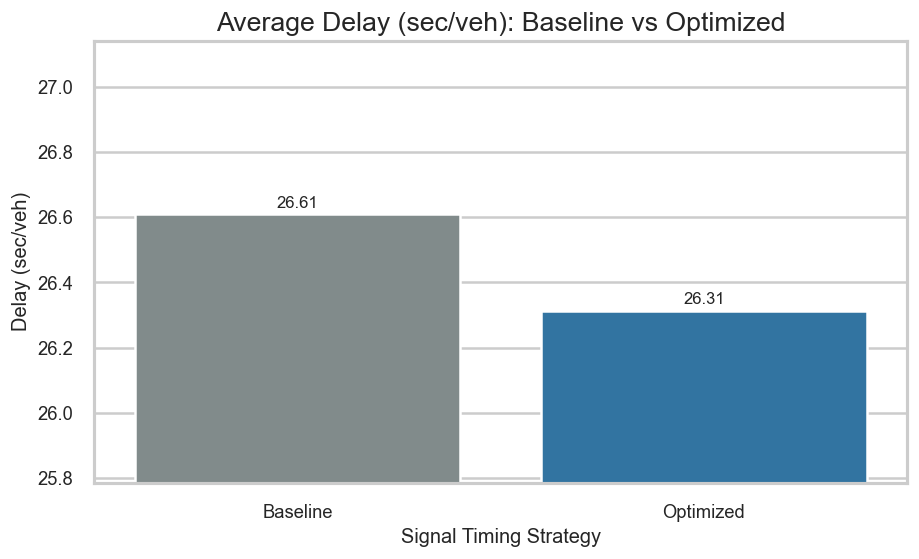

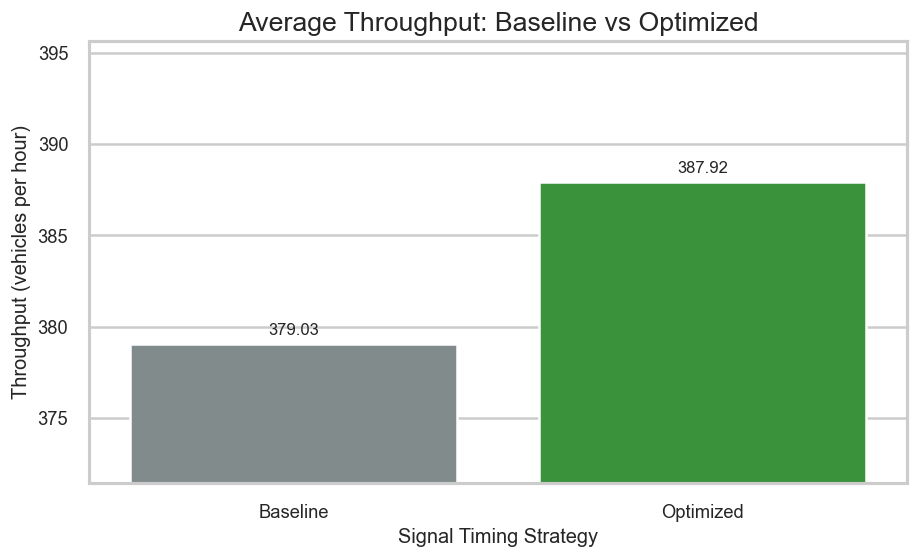

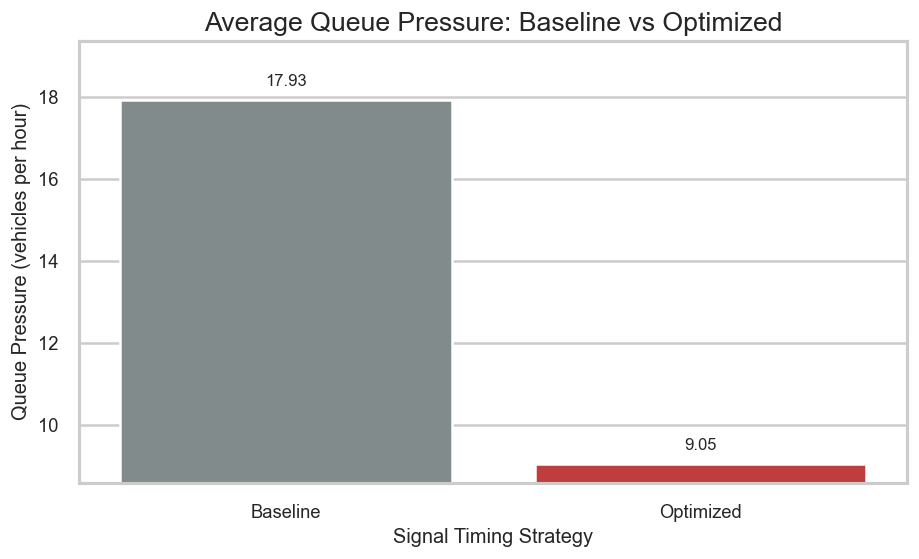

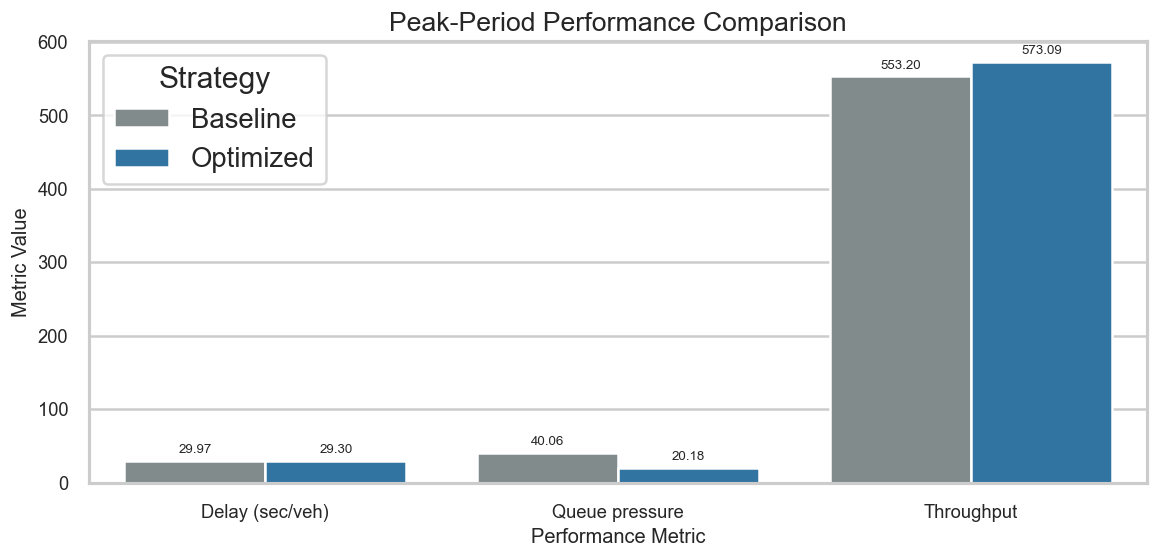

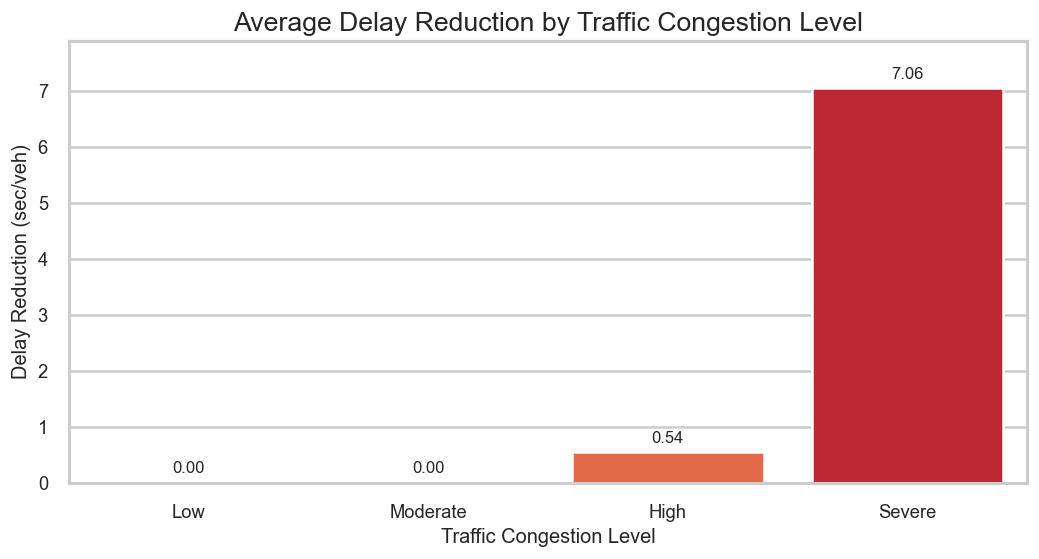

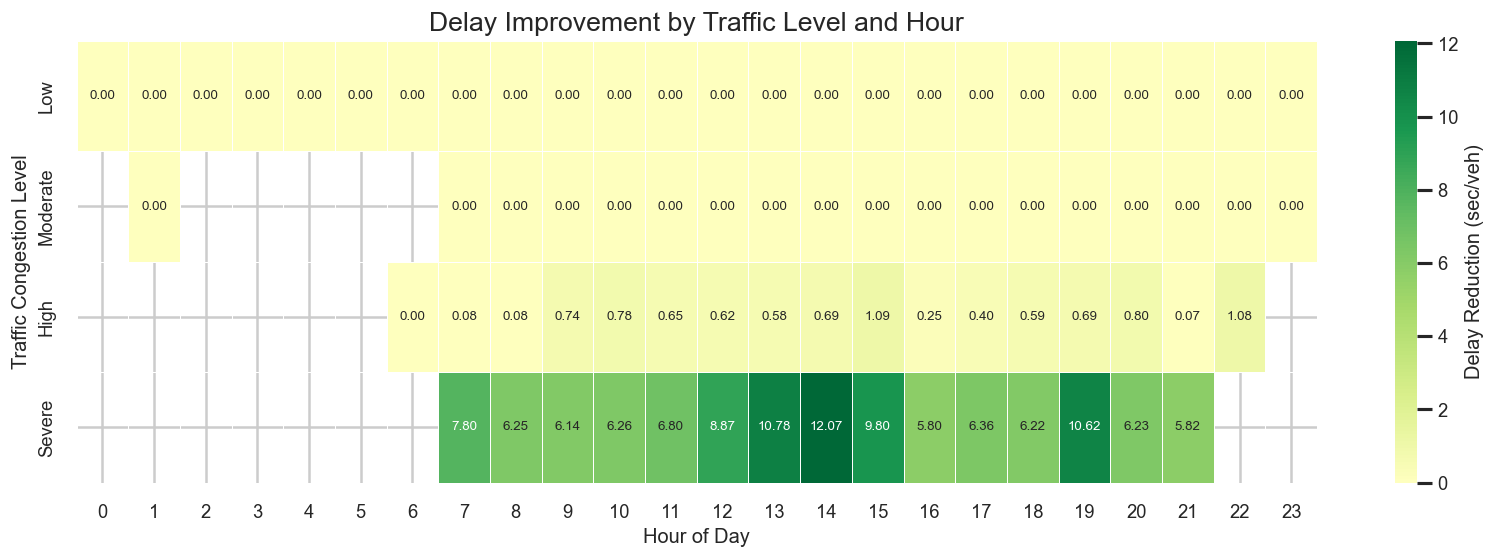

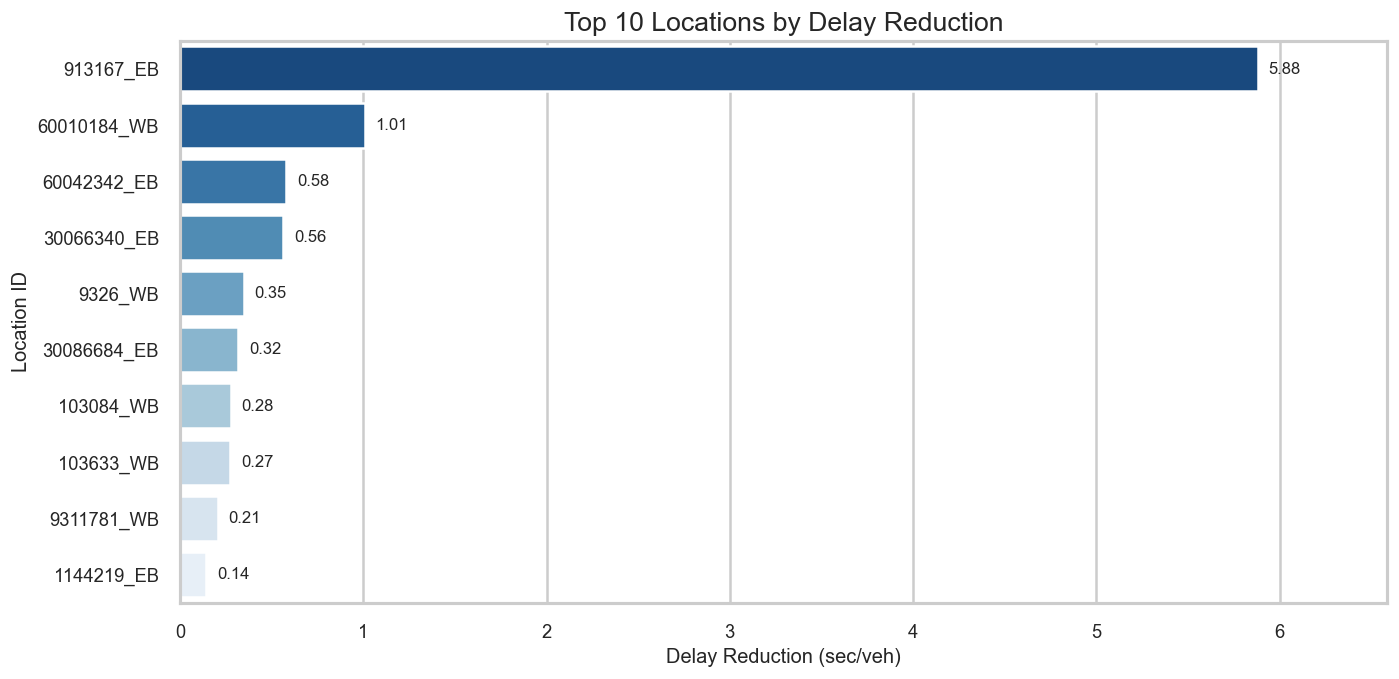

In [120]:
comparison_plot_df = pd.DataFrame({
    'Strategy': ['Baseline', 'Optimized'],
    'Average delay (sec/veh)': [analysis_df['baseline_delay_sec'].mean(), analysis_df['optimized_delay_sec'].mean()],
    'Average throughput': [analysis_df['baseline_throughput'].mean(), analysis_df['optimized_throughput'].mean()],
    'Average queue pressure': [analysis_df['baseline_queue_pressure'].mean(), analysis_df['optimized_queue_pressure'].mean()],
})

label_fs = 10
bar_label_fs = 8

# --- Average Delay ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=comparison_plot_df,
    x='Strategy',
    y='Average delay (sec/veh)',
    hue='Strategy',
    palette=['#7f8c8d', '#1f77b4'],
    legend=False,
    ax=ax
)
ax.set_title('Average Delay (sec/veh): Baseline vs Optimized')
ax.set_ylabel('Delay (sec/veh)')
ax.set_xlabel('Signal Timing Strategy')

delay_values = comparison_plot_df['Average delay (sec/veh)'].to_numpy()
ax.set_ylim(delay_values.min() * 0.98, delay_values.max() * 1.02)

delay_offset = (delay_values.max() - delay_values.min()) * 0.04
if delay_offset == 0:
    delay_offset = delay_values.max() * 0.005

for i, v in enumerate(delay_values):
    ax.text(i, v + delay_offset, f'{v:.2f}', ha='center', va='bottom', fontsize=label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'signal_timing_delay_comparison.png', bbox_inches='tight')
plt.show()

# --- Average Throughput ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=comparison_plot_df,
    x='Strategy',
    y='Average throughput',
    hue='Strategy',
    palette=['#7f8c8d', '#2ca02c'],
    legend=False,
    ax=ax
)
ax.set_title('Average Throughput: Baseline vs Optimized')
ax.set_ylabel('Throughput (vehicles per hour)')
ax.set_xlabel('Signal Timing Strategy')

throughput_values = comparison_plot_df['Average throughput'].to_numpy()
ax.set_ylim(throughput_values.min() * 0.98, throughput_values.max() * 1.02)

throughput_offset = (throughput_values.max() - throughput_values.min()) * 0.04
if throughput_offset == 0:
    throughput_offset = throughput_values.max() * 0.005

for i, v in enumerate(throughput_values):
    ax.text(i, v + throughput_offset, f'{v:.2f}', ha='center', va='bottom', fontsize=label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'signal_timing_throughput_comparison.png', bbox_inches='tight')
plt.show()

# --- Average Queue Pressure ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=comparison_plot_df,
    x='Strategy',
    y='Average queue pressure',
    hue='Strategy',
    palette=['#7f8c8d', '#d62728'],
    legend=False,
    ax=ax
)
ax.set_title('Average Queue Pressure: Baseline vs Optimized')
ax.set_ylabel('Queue Pressure (vehicles per hour)')
ax.set_xlabel('Signal Timing Strategy')

queue_values = comparison_plot_df['Average queue pressure'].to_numpy()
ax.set_ylim(queue_values.min() * 0.95, queue_values.max() * 1.08)

queue_offset = (queue_values.max() - queue_values.min()) * 0.03
if queue_offset == 0:
    queue_offset = queue_values.max() * 0.005

for i, v in enumerate(queue_values):
    ax.text(i, v + queue_offset, f'{v:.2f}', ha='center', va='bottom', fontsize=label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'signal_timing_queue_pressure_comparison.png', bbox_inches='tight')
plt.show()

# --- Peak-Period Performance Comparison ---
peak_plot_df = peak_summary.melt(
    id_vars='Metric',
    value_vars=['Baseline', 'Optimized'],
    var_name='Strategy',
    value_name='Value'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=peak_plot_df,
    x='Metric',
    y='Value',
    hue='Strategy',
    palette=['#7f8c8d', '#1f77b4'],
    ax=ax
)
ax.set_title('Peak-Period Performance Comparison')
ax.set_ylabel('Metric Value')
ax.set_xlabel('Performance Metric')
ax.legend(title='Strategy')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=bar_label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'signal_timing_peak_period_comparison.png', bbox_inches='tight')
plt.show()

# --- Average Delay Reduction by Traffic Congestion Level ---
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=congestion_summary,
    x='traffic_level',
    y='delay_reduction_sec',
    palette='YlOrRd',
    ax=ax
)
ax.set_title('Average Delay Reduction by Traffic Congestion Level')
ax.set_xlabel('Traffic Congestion Level')
ax.set_ylabel('Delay Reduction (sec/veh)')

congestion_values = congestion_summary['delay_reduction_sec'].to_numpy()
congestion_upper = congestion_values.max() * 1.12 if congestion_values.max() > 0 else 1
ax.set_ylim(0, congestion_upper)

for i, v in enumerate(congestion_values):
    ax.text(i, v + congestion_upper * 0.015, f'{v:.2f}', ha='center', va='bottom', fontsize=label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'delay_reduction_by_congestion_level.png', bbox_inches='tight')
plt.show()

# --- Delay Improvement Heatmap ---
heatmap_df = analysis_df.pivot_table(
    values='delay_reduction_sec',
    index='traffic_level',
    columns='hour',
    aggfunc='mean',
    observed=False,
)
heatmap_df = heatmap_df.reindex(traffic_level_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_df,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': 'Delay Reduction (sec/veh)'},
    ax=ax,
)
ax.set_title('Delay Improvement by Traffic Level and Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Traffic Congestion Level')

fig.tight_layout()
fig.savefig(figures_dir / 'signal_timing_congestion_heatmap.png', bbox_inches='tight')
plt.show()

# --- Top 10 Locations by Delay Reduction ---
top_locations_plot_df = location_summary_df.head(10).copy()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=top_locations_plot_df,
    y='location_id',
    x='delay_reduction_sec',
    palette='Blues_r',
    ax=ax
)
ax.set_title('Top 10 Locations by Delay Reduction')
ax.set_xlabel('Delay Reduction (sec/veh)')
ax.set_ylabel('Location ID')

max_delay = top_locations_plot_df['delay_reduction_sec'].max()
ax.set_xlim(0, max_delay * 1.12)

for i, v in enumerate(top_locations_plot_df['delay_reduction_sec'].to_numpy()):
    ax.text(v + max_delay * 0.01, i, f'{v:.2f}', va='center', fontsize=label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'top_location_improvements.png', bbox_inches='tight')
plt.show()

## 15. Conclusion and Recommendations

The fixed-time baseline remains useful as a transparent benchmark, but the demand-responsive timing strategy performs better when forecasted demand intensifies because green time is allocated in line with expected operating conditions and cycle length can extend modestly under heavier congestion. Within the scope of this simplified comparative analysis, the optimized strategy demonstrates lower estimated control delay, smaller queue buildup, and higher throughput, with the largest gains appearing under higher congestion conditions and during peak periods. These results support the capstone objective of using forecast-driven signal allocation to inform smarter traffic operations. Future work should extend this notebook with calibrated delay estimation, formal signal optimization, queueing or microsimulation tools such as SUMO, and advanced adaptive control methods including reinforcement learning.
